# Lab Work 3: Classification of Image Data

## 1 Load the MNIST Data-Set
* get the data using code below
* assemble information on number of images, size of images, distribution among different classes

In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd
from math import sqrt

In [2]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

c:\Users\alant\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


### Create Dataframe for better understanding

In [3]:
data = pd.DataFrame(X, columns=X.columns)
data

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Columns are the pixels of the image. Each row is an image. 

In [4]:
# Number of images
num_images = len(data)

num_columns = len(data.columns)

# Size of images
image_size = int(sqrt(X.shape[1]))

# Distribution among different classes
class_distribution = pd.Series(y).value_counts()

print("Number of Images:", num_images)
print("Number of Columns:", num_columns)
print("Size of Images:", image_size, "x", image_size)
print("Distribution among Different Classes:")
print(class_distribution)

Number of Images: 70000
Number of Columns: 784
Size of Images: 28 x 28
Distribution among Different Classes:
class
1    7877
7    7293
3    7141
2    6990
9    6958
0    6903
6    6876
8    6825
4    6824
5    6313
Name: count, dtype: int64


The result shows that there are 70,000 images in the dataset. Each image is a 28 x 28 pixel image. The images are distributed among 10 classes. Each class represents a digit from 0 to 9.
All classes have between roundabout 6000 and 8000 images. We have 784 columns in the dataset. Each column represents one pixel of the image. The pixel values are between 0 and 255.
With 784 columns, it seems to me that the dataset has a high dimensionality, which can have a negative impact on the models, such as overfitting and computational efficiency. 

In the following cells, I will try to reduce the dimensionality without losing useful information that models can use for training in order to make efficient predictions.

### Normalize The Mnist Dataset

We normalize the data by using [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler) from `sklearn.preprocessing`. This will scale the data between 0 and 1.

In [5]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

normalized_X = MinMaxScaler().fit_transform(X)

Normalizing the data is important because it brings all the values into the same range. This helps in faster computation of the algorithms/models. It also helps in bringing the data to a common scale, which is important for machine learning algorithms that use euclid distances. 

### Principal Component Analysis (PCA)

Now I compress the data using PCA to a degree that preserves 95% variance of the data and only looses 5%.

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components = .95)
decromposed_and_normalized_X = pca.fit_transform(normalized_X)

Because we have a dataset with high dimensionality, we will use PCA to reduce the number of features. We will reduce the number of features to 95% of the variance. This will reduce the number of features from 784 to 154. We will then use the reduced dataset to train our different models. 

In [7]:
display("Original data", data.describe(), "Transformed data", pd.DataFrame(decromposed_and_normalized_X).describe())

'Original data'

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.197414,0.099543,0.046629,0.016614,0.012957,0.001714,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.991206,4.256304,2.783732,1.561822,1.553796,0.320889,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.000000,0.0,0.0,0.0,0.0


'Transformed data'

,0,1,2,3,4,5,6,7,8,9,...,144,145,146,147,148,149,150,151,152,153
count,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,...,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04,7.000000e+04
mean,-3.930316e-16,4.827630e-16,-4.612437e-16,-1.916435e-16,-9.744586e-17,5.830511e-16,-2.793448e-16,-1.216043e-16,1.177471e-16,-6.130969e-17,...,4.369838e-17,1.877863e-18,5.690686e-17,-1.834723e-17,-3.194905e-17,4.977606e-17,5.811225e-18,-2.157005e-17,5.595524e-17,1.498484e-17
std,2.267379e+00,1.942794e+00,1.801065e+00,1.688268e+00,1.605889e+00,1.506976e+00,1.315013e+00,1.234612e+00,1.206241e+00,1.111514e+00,...,1.617275e-01,1.611547e-01,1.597475e-01,1.592708e-01,1.577182e-01,1.569042e-01,1.564861e-01,1.561083e-01,1.554808e-01,1.539839e-01
min,-4.239784e+00,-5.603369e+00,-5.599050e+00,-5.981002e+00,-5.089137e+00,-4.876769e+00,-4.378558e+00,-4.497439e+00,-4.286288e+00,-3.909004e+00,...,-8.104157e-01,-7.020981e-01,-8.431396e-01,-8.169049e-01,-7.324898e-01,-7.512295e-01,-7.775775e-01,-7.456138e-01,-8.155131e-01,-7.545585e-01
25%,-1.564450e+00,-1.429642e+00,-1.280764e+00,-1.212729e+00,-1.082010e+00,-1.032434e+00,-9.372892e-01,-8.300007e-01,-8.606427e-01,-7.087979e-01,...,-1.055983e-01,-1.009565e-01,-1.023676e-01,-9.999004e-02,-1.025587e-01,-1.019131e-01,-1.019093e-01,-9.924591e-02,-1.016090e-01,-9.979965e-02
50%,-1.948233e-01,-3.221344e-01,6.709407e-02,1.876001e-02,3.859943e-02,4.404052e-02,-6.307329e-02,-1.202279e-01,-5.285177e-02,4.639608e-02,...,-9.612735e-04,-1.184380e-04,-9.826507e-04,-8.669382e-04,-1.052114e-03,2.689415e-04,1.578036e-04,-1.593074e-04,-1.771733e-03,5.568204e-04
75%,1.310065e+00,1.509970e+00,1.255041e+00,1.067100e+00,1.095563e+00,1.046656e+00,8.869000e-01,7.769083e-01,8.156731e-01,7.848075e-01,...,1.041550e-01,1.009495e-01,1.022001e-01,1.006403e-01,1.021436e-01,1.003864e-01,1.020345e-01,9.966441e-02,9.980284e-02,1.004506e-01
max,9.348955e+00,5.742932e+00,5.788564e+00,6.213921e+00,5.445528e+00,5.001733e+00,4.978096e+00,4.668857e+00,5.923509e+00,4.015872e+00,...,8.988665e-01,8.421430e-01,9.354809e-01,8.343631e-01,8.528361e-01,7.932256e-01,8.156433e-01,8.124339e-01,9.033212e-01,7.546655e-01


We see compared to the original data, the transformed data has a much smaller standard deviation and a much smaller range of values. This is because the data has been normalized. The mean is also much closer to 0. The number of columns is reduced by combining columns that are highly correlated with each other. The number of columns is reduced to 154 because this is the number of columns that are needed to retain 95% of the information in the dataset. This is because we set `n_components to .95` when we created the PCA object. 

I now undo the compression by employing PCA reverse transform. Although this process restores the dataset to its original state with 784 features, the information lost (5%) during compression remains unrecoverable.

In [8]:
X_decompressed = pca.inverse_transform(decromposed_and_normalized_X)

## 2 Visualize the input data
* Display at least two images for each class in the dataset
* Show the class identity per image

In [9]:
import matplotlib.pyplot as plt

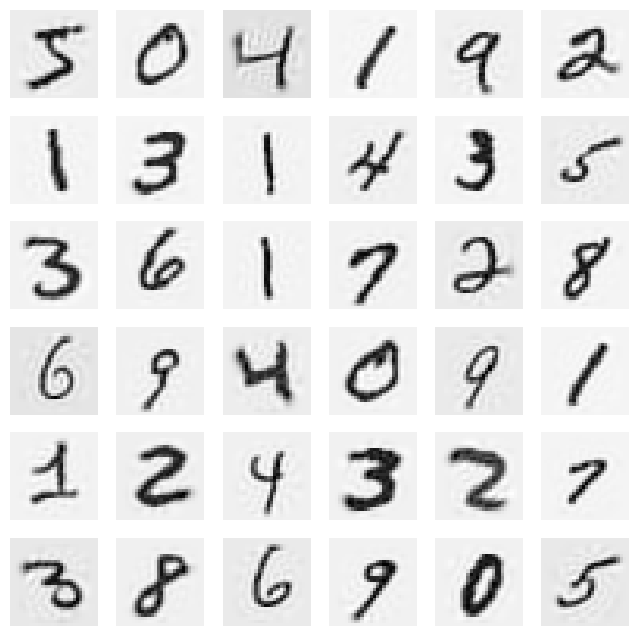

In [10]:
def plot_digits(data, row_size=5):
    plt.figure(figsize=(8,8))
    for i in range(len(data)):
        ax = plt.subplot(row_size, row_size, i+1)
        digit_image = data[i].reshape(28, 28)
        plt.imshow(digit_image, cmap="Greys")
        plt.axis("off")

plot_digits(X_decompressed[:36], row_size=6)
plt.show()

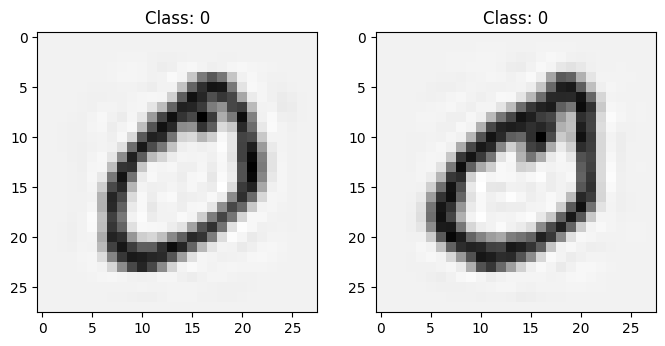

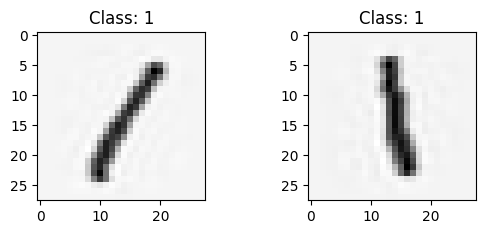

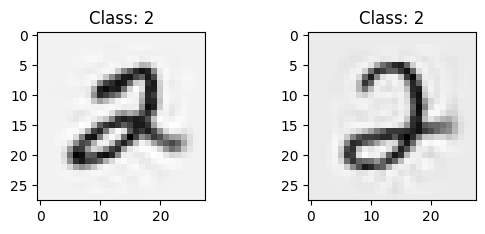

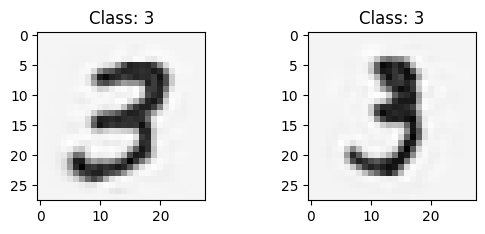

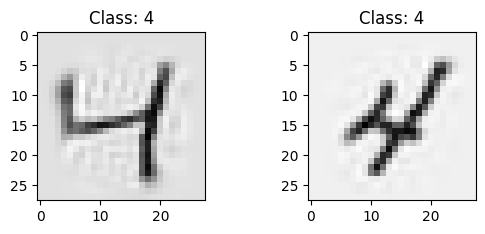

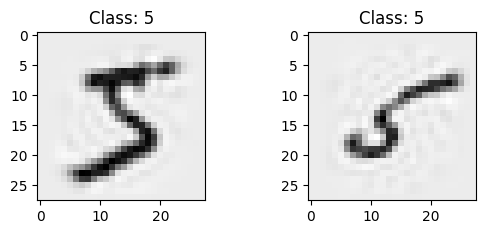

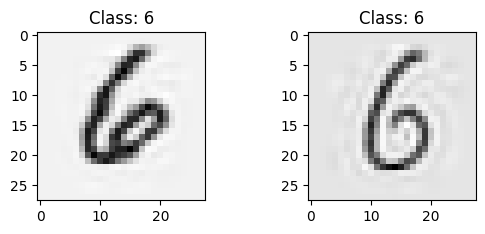

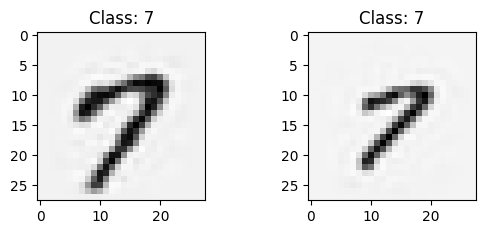

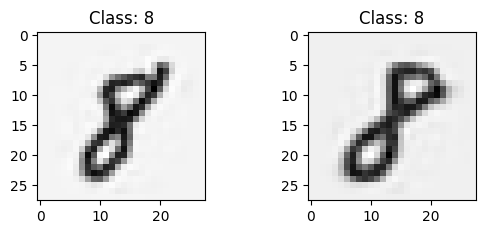

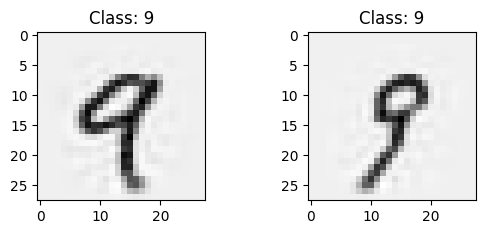

In [11]:
labels = y.astype('int')
labels = np.unique(labels)


plt.figure(figsize=(8,8))
for label in labels:
    count = 0
    for i in range(len(X)):
        if int(y[i]) == label:
            plt.subplot(2, 2, count + 1)
            plt.imshow(X_decompressed[i].reshape(28, 28), cmap="Greys")
            plt.title('Class: {}'.format(label))
            count += 1
            if count == 2:
                break
    plt.show()
    if count == 2:
        continue

## 3 Train a k-NN Classifier and Check the Performance

### 3.1 Import the required modules for classifier and performance measurement

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

### 3.2 Train the classifier using 3-fold cross_validation 
* create a training and testing set
* train the classifer with cross_validate, check the documentation: What does cross_validate return?

In [32]:
X_train, X_test, y_train, y_test = train_test_split(decromposed_and_normalized_X, y, test_size=0.2, random_state=42)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')

# train the classifier
best_classifier = knn.fit(X_train, y_train)

# Predict the labels for the test set
y_pred_knn = best_classifier.predict(X_test)

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(knn, X_train, y_train, cv=3, scoring=scoring)



The KNN is configured with `n_neighbors=3`, which means it will consider the 3 nearest neighbors when making predictions, and `weights='distance'`, which means closer neighbors will have a greater influence on the prediction.

The `fit()` method adjusts the parameters of the classifier based on the training data, so that it can make accurate predictions.

After training the classifier, the code proceeds to predict the labels for the test set using the `predict()` method.

the `cross_validate()` function is called to perform cross-validation on the `knn` classifier.

On the question of what cross_validate returns: The `cross_validate` function in sklearn performs cross-validation and returns a dictionary with adaptation times, scoring times and test results for each fold. If `return_train_score=True` is passed, it also contains the training results.

### 3.3 Use the best classifier from the previuous run and check with your test set 
* Generate a classification report
* Generate a confusion matrix

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Accuracy: 0.972428563438906
Precision: 0.9726125957208671
Recall: 0.9720323827060487
F1-score: 0.972221297720437

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.97      0.99      0.98      1600
           2       0.98      0.97      0.97      1380
           3       0.97      0.97      0.97      1433
           4       0.98      0.97      0.97      1295
           5       0.98      0.97      0.97      1273
           6       0.98      0.99      0.99      1396
           7       0.97      0.98      0.98      1503
           8       0.98      0.95      0.97      1357
           9       0.96      0.97      0.96      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.97      0.98     14000
weighted avg       0.98      0.98      0.98     14000

Confusion Matrix:


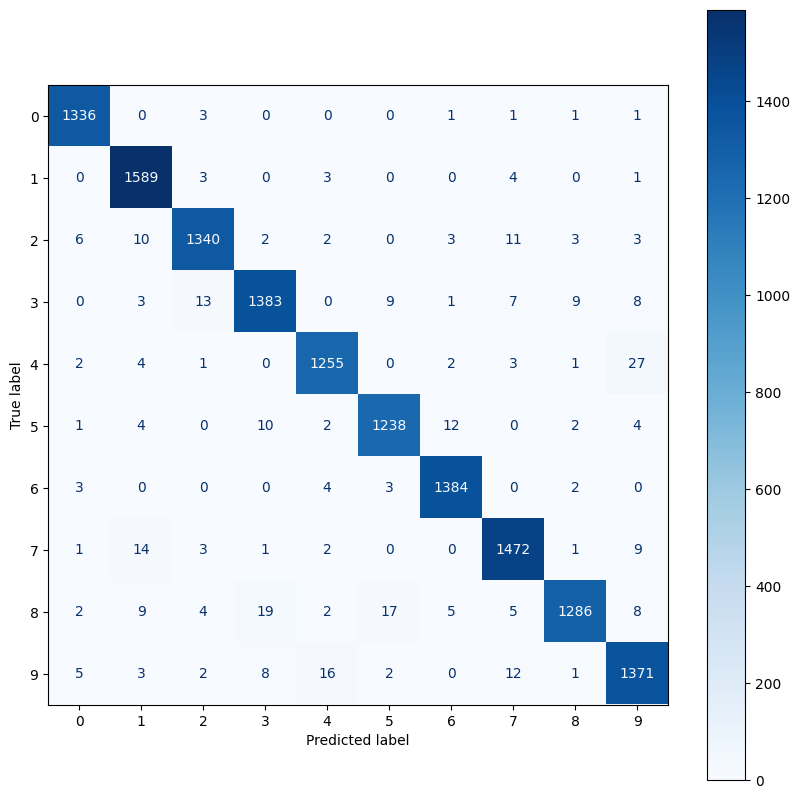

In [41]:
print("Accuracy:", cv_results['test_accuracy'].mean())
print("Precision:", cv_results['test_precision_macro'].mean())
print("Recall:", cv_results['test_recall_macro'].mean())
print("F1-score:", cv_results['test_f1_macro'].mean())

# Generate the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Generate the confusion matrix
print("Confusion Matrix:")
cf_mat_KNN = confusion_matrix(y_test, y_pred_knn)

cm_fig, cm_ax = plt.subplots(figsize=(10, 10))
cf_mat_disp = ConfusionMatrixDisplay(cf_mat_KNN)
cf_mat_disp.plot(ax=cm_ax, cmap=plt.cm.Blues)
plt.show()

The overall accuracy of the model is 0.9724, which means that the model correctly predicted the class for about 97.24% of the instances in the test set.

The macro-averaged precision, recall, and F1-score are all around 0.97, which indicates that the model has a balanced performance across all classes, not favoring any particular class.

The classification report provides a detailed view of the model's performance for each class. For all classes, the precision, recall, and F1-score are quite high (all values are close to or above 0.95), which indicates that the model performs well for each individual class.

Class 0 has the highest precision and recall, both at 0.99, indicating that the model is particularly good at predicting this class correctly and not confusing it with other classes.

Class 9 has the lowest precision and recall, both at 0.96, but these are still quite high values, indicating good performance.

The weighted average precision, recall, and F1-score are all 0.98, which takes into account the number of instances in each class. This indicates that the model performs well overall.

# 4 Train a Decision Tree Classifier and Check the Performance

In the following cells we will use the functions `fit()` and `predict()` as before, but change the classifier depending on the task

Next, we define a parameter grid called `param_grid`. This grid specifies the different combinations of hyperparameters that we want to test during the grid search. In this case, we are specifying the values for four hyperparameters: `criterion`, `max_depth` `min_samples_split`, and `min_samples_leaf`. For each hyperparameter, we provide a list of possible values to be tested.
 
The `GridSearchCV` object will perform an exhaustive search over the specified parameter grid and evaluate the performance of each combination using cross-validation.

We fit the `GridSearchCV` object to the training data by calling the `fit()` method and passing in the training features `X_train` and labels `y_train`. This will perform the grid search and identify the best combination of hyperparameters based on the specified scoring metric.

This code section performs hyperparameter tuning for a decision tree classifier using grid search. It searches for the best combination of hyperparameters specified in the `param_grid` and prints the best parameters found.

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create the Decision Tree Classifier
decision_tree = DecisionTreeClassifier()

# Create the GridSearchCV object
grid_search = GridSearchCV(decision_tree, param_grid, cv=3)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_

# Print the best parameters
print("Best Parameters:", best_params)




Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


Now we train the Decision Tree Classifier with the optimal hyperparameters, which we obtain before.

In [43]:
# Train the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(criterion='entropy', max_depth=None, min_samples_leaf=4, min_samples_split=2)
decision_tree.fit(X_train, y_train)

# Predict the labels for the test set
y_pred_decision_tree = decision_tree.predict(X_test)

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1343
           1       0.95      0.97      0.96      1600
           2       0.82      0.85      0.83      1380
           3       0.79      0.80      0.79      1433
           4       0.79      0.83      0.81      1295
           5       0.79      0.79      0.79      1273
           6       0.90      0.90      0.90      1396
           7       0.89      0.87      0.88      1503
           8       0.79      0.76      0.78      1357
           9       0.79      0.75      0.77      1420

    accuracy                           0.84     14000
   macro avg       0.84      0.84      0.84     14000
weighted avg       0.84      0.84      0.84     14000

Confusion Matrix:


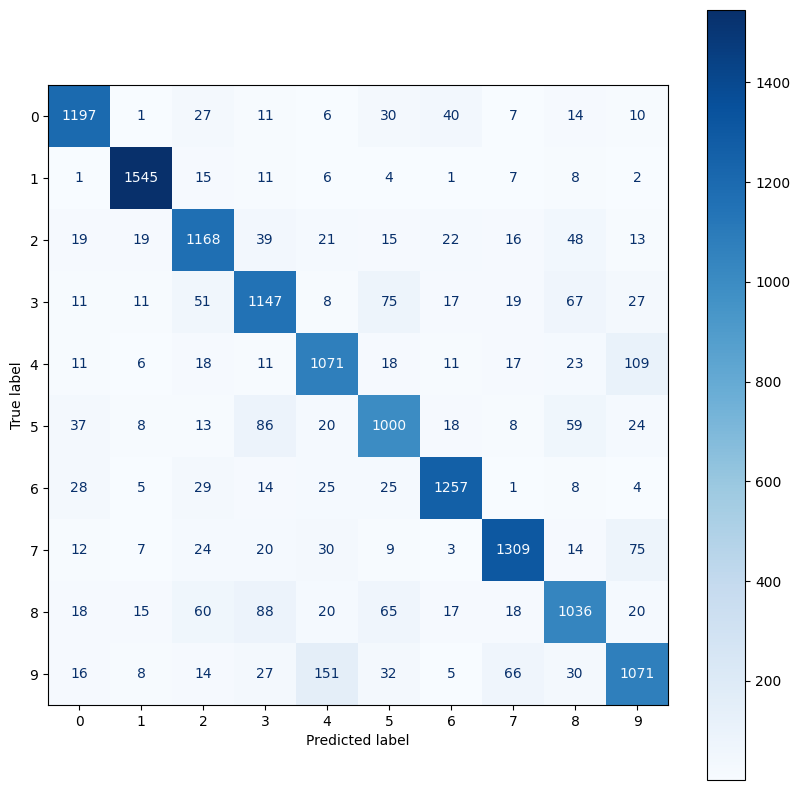

In [44]:
# Generate the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_decision_tree))

# Generate the confusion matrix
print("Confusion Matrix:")
cf_mat_Decision_tree = confusion_matrix(y_test, y_pred_decision_tree)

cm_fig, cm_ax = plt.subplots(figsize=(10, 10))
cf_mat_disp = ConfusionMatrixDisplay(cf_mat_Decision_tree)
cf_mat_disp.plot(ax=cm_ax, cmap=plt.cm.Blues)
plt.show()

The model boasts an overall accuracy of 0.84, indicating its correct classification of approximately 84% of instances in the test set.

Averaged precision, recall, and F1-score, all standing at 0.84, signify a well-balanced performance across all classes without favoring any particular class.

The classification report offers a comprehensive view of the model's class-specific performance, with precision, recall, and F1-score ranging between 0.79 and 0.95 for all classes. This variability suggests differing performance levels across classes, exemplified by class 1, which showcases the model's excellence with precision and recall both at 0.97, demonstrating accurate predictions for this class without confusion.

The weighted average precision, recall, and F1-score, all at 0.84, consider class instances, indicating the model's commendable overall performance.

In conclusion, the model attains respectable accuracy and balanced precision, recall, and F1-score values across all classes, reflecting commendable performance in the classification task. Nonetheless, there is room for improvement, especially for classes where precision, recall, and F1-score are lower.

### 4.1 Train the classifier using 3-fold cross_validation

The code evaluates the performance of the `decision_tree` classifier using 3-fold cross-validation and returns an array of accuracy scores, one for each fold od cross-validation

In [45]:
from sklearn.model_selection import cross_val_score

# Train the classifier using 3-fold cross-validation
scores = cross_val_score(decision_tree, X_train, y_train, cv=3)

# Print the average accuracy across all folds
print("Average Accuracy:", scores.mean())



Average Accuracy: 0.8296964829918497


### 4.2 Check the performance with your test set

In [46]:
# Check the performance with your test set
accuracy = decision_tree.score(X_test, y_test)
print("Accuracy:", accuracy)


Accuracy: 0.8429285714285715


## 5 Improve with random forests

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest Classifier
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# Predict the labels for the test set
y_pred_random_forest = random_forest.predict(X_test)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1343
           1       0.97      0.98      0.98      1600
           2       0.94      0.95      0.94      1380
           3       0.92      0.93      0.93      1433
           4       0.94      0.95      0.94      1295
           5       0.94      0.94      0.94      1273
           6       0.97      0.97      0.97      1396
           7       0.96      0.95      0.95      1503
           8       0.93      0.90      0.91      1357
           9       0.94      0.92      0.93      1420

    accuracy                           0.95     14000
   macro avg       0.95      0.95      0.95     14000
weighted avg       0.95      0.95      0.95     14000

Confusion Matrix:


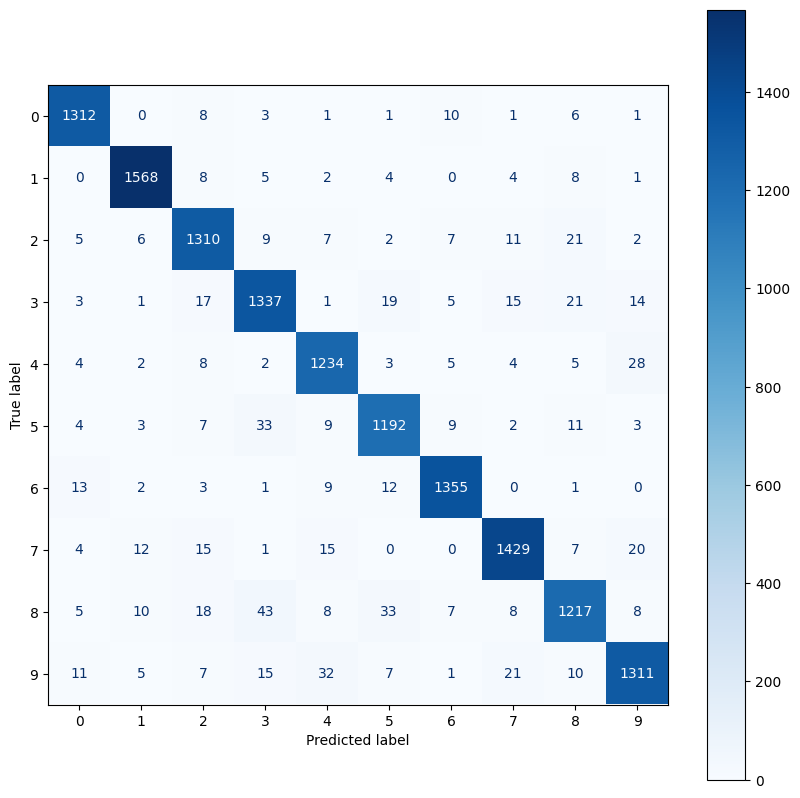

In [49]:
# Generate the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_random_forest))

# Generate the confusion matrix
print("Confusion Matrix:")
cf_mat_Random_forest = confusion_matrix(y_test, y_pred_random_forest)

cm_fig, cm_ax = plt.subplots(figsize=(10, 10))
cf_mat_disp = ConfusionMatrixDisplay(cf_mat_Random_forest)
cf_mat_disp.plot(ax=cm_ax, cmap=plt.cm.Blues)
plt.show()

The model demonstrates an impressive overall accuracy of 0.95, accurately predicting the class for approximately 95% of instances in the test set.

Macro-averaged precision, recall, and F1-score, all hovering around 0.95, highlight the model's balanced performance across all classes.

The classification report furnishes a detailed perspective on the model's performance for each class, with precision, recall, and F1-score ranging between 0.92 and 0.98 for all classes. This variability indicates superior performance for certain classes, exemplified by class 1, with the highest precision and recall at 0.98, showcasing the model's proficiency in accurately predicting this class without confusion.

The weighted average precision, recall, and F1-score, all at 0.95, consider class instances, affirming the model's strong overall performance

The Random Forest model has achieved high accuracy and balanced precision, recall, and F1-score values across all classes, indicating excellent performance on the classification task.

## 6 Further improvement: Gradient Boosting (Random Forests)

This code trains a gradient boosting classifier using the provided training data `X_train` and `y_train`, and then uses the trained classifier to predict labels for the test data `X_test`. The predicted labels are stored in the variable `y_pred_gradient_boosting`.

Next, a `GradientBoostingClassifier` object named `gradient_boosting` is created. The object is initialized with several parameters:
   - `learning_rate=0.1`: This parameter controls the step size at each boosting iteration. A lower learning rate makes the model more conservative.
   - `n_iter_no_change=5`: This parameter specifies the maximum number of consecutive iterations without improvement before the training process is stopped.
   - `tol=0.01`: This parameter sets the tolerance for the early stopping criterion. If the improvement in the loss function is less than this value, the training process stops.
   - `verbose=1`: This parameter controls the verbosity of the training process. A value of 1 means that progress messages will be printed during training.

In [25]:
from sklearn.ensemble import GradientBoostingClassifier

# Train the Gradient Boosting Classifier
gradient_boosting = GradientBoostingClassifier(learning_rate=0.1, n_iter_no_change=5, tol=0.01, verbose=1)
gradient_boosting.fit(X_train, y_train)

# Predict the labels for the test set
y_pred_gradient_boosting = gradient_boosting.predict(X_test)

      Iter       Train Loss   Remaining Time 
         1           1.9014           68.66m
         2           1.6859           68.03m
         3           1.5283           67.42m
         4           1.4001           66.79m
         5           1.2988           66.04m
         6           1.2117           65.30m
         7           1.1371           64.59m
         8           1.0722           63.89m
         9           1.0149           63.16m
        10           0.9640           62.50m
        20           0.6528           55.89m
        30           0.5008           48.97m
        40           0.4127           41.94m
        50           0.3539           34.96m
        60           0.3128           27.97m
        70           0.2795           20.92m
        80           0.2548           13.90m


The reason why I chose this parameter for the gradient boosting classifier is that the execution time was too long and my program did not terminate. The consequence was that I chose the above parameters to observe the training to make sure everything was working properly.

In the end it worked correctly, but the execution time was much higher than the previous models. This can be attributed to the gradient boosting classifier as it is more time-consuming to run the program.

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1343
           1       0.96      0.98      0.97      1600
           2       0.93      0.90      0.91      1380
           3       0.90      0.90      0.90      1433
           4       0.90      0.90      0.90      1295
           5       0.88      0.89      0.88      1273
           6       0.94      0.96      0.95      1396
           7       0.94      0.93      0.93      1503
           8       0.90      0.88      0.89      1357
           9       0.89      0.89      0.89      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000

Confusion Matrix:


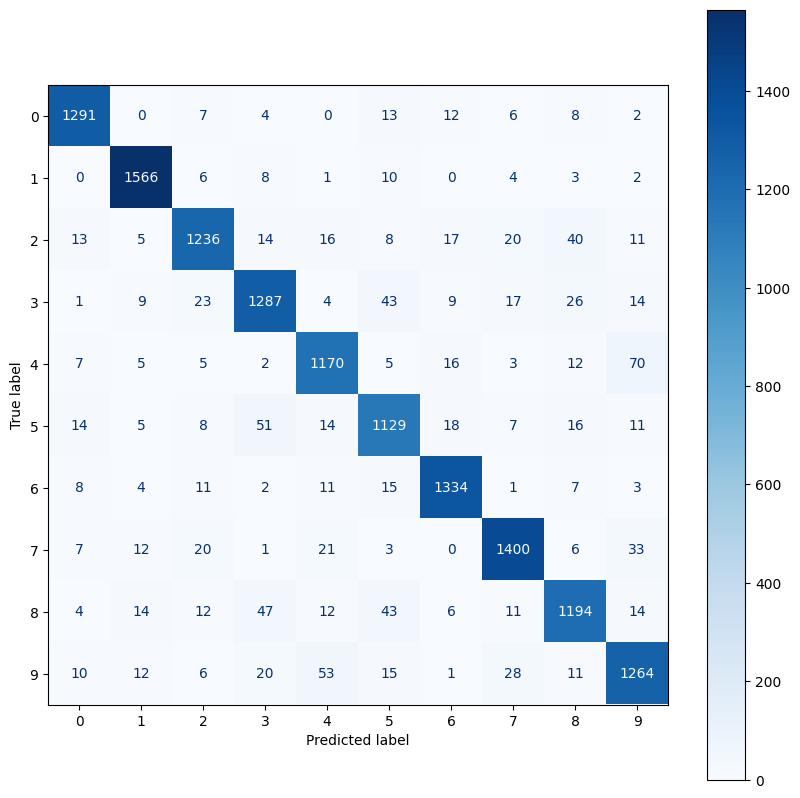

In [26]:
# Generate the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_gradient_boosting))

# Generate the confusion matrix
print("Confusion Matrix:")
cf_mat_gradient_boosting = confusion_matrix(y_test, y_pred_gradient_boosting)

cm_fig, cm_ax = plt.subplots(figsize=(10, 10))
cf_mat_disp = ConfusionMatrixDisplay(cf_mat_gradient_boosting)
cf_mat_disp.plot(ax=cm_ax, cmap=plt.cm.Blues)
plt.show()

The overall accuracy of the model is 0.92, which means that the model correctly predicted the class for about 92% of the instances in the test set.

The macro-averaged precision, recall, and F1-score are all around 0.92, which indicates that the model has a balanced performance across all classes, not favoring any particular class.

The classification report provides a detailed view of the model's performance for each class. For all classes, the precision, recall, and F1-score vary between 0.88 and 0.96. This indicates that the model performs better for some classes than others. For example, class 1 has the highest precision and recall, both at 0.98, indicating that the model is particularly good at predicting this class correctly and not confusing it with other classes.

The weighted average precision, recall, and F1-score are all 0.92, which takes into account the number of instances in each class.

In conclusion, The Gradient Boosting Classifier model has achieved high accuracy and balanced precision, recall, and F1-score values across all classes, indicating very good performance on the classification task. 

## Sources

* https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
* https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
* https://www.kaggle.com/code/pranaysingh25/dimensionality-reduction-visualization-mnist
